# Figure 3: 2D map of SFs from a 2D simulation

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, SymLogNorm
import matplotlib.ticker as ticker
import pyturbo_sf as psf
import pyproj
import numpy as np
linewidth = 2
fontsize = 12
plt.rcParams['xtick.labelsize'] = fontsize
plt.rcParams['ytick.labelsize'] = fontsize
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['ytick.minor.width'] = 2
plt.rcParams['xtick.major.size'] = 10
plt.rcParams['xtick.minor.size'] = 5
plt.rcParams['ytick.major.size'] = 10
plt.rcParams['ytick.minor.size'] = 5
plt.rcParams['savefig.dpi'] = 150
plt.rc('font', family='serif')
import gc

# Load the CROCO Dataset

In [2]:
path_data = '/home/aayouche/warrior/data'
idt = 10
dsh = xr.open_dataset(path_data+'/'+'surface.nc')
dsg = xr.open_dataset(path_data+'/'+'GOM_150_grd.nc')

lon = dsg.lon_rho
lat = dsg.lat_rho

lon_center = np.nanmin(lon)
utm_zone = int(1 + (lon_center + 180.0) / 6.0)

# Create the projection
proj = pyproj.Proj(proj='utm', zone=utm_zone, ellps='WGS84', datum='WGS84')

x, y = proj(lon.values, lat.values) 

X = 0.25*(x[1:,1:] + x[1:,:-1] + x[:-1,:-1] + x[:-1,1:])
Y = 0.25*(y[1:,1:] + y[1:,:-1] + y[:-1,:-1] + y[:-1,1:])


u = np.array(dsh.u.isel(s_rho=0,time=idt))
u = 0.5*(u[1:,:] + u[:-1,:])
v = np.array(dsh.v.isel(s_rho=0,time=idt))
v = 0.5*(v[:,1:] + v[:,:-1])

dudx = np.gradient(u,axis=1)/(2*150.)
dvdx = np.gradient(v,axis=1)/(2*150.)
dudy = np.gradient(u,axis=0)/(2*150.)
dvdy = np.gradient(v,axis=0)/(2*150.)

adv_u = u*dudx + v*dudy

adv_v = v*dudx + v*dvdy

temp = np.array(dsh.temp.isel(s_rho=0,time=idt))

temp = 0.25*(temp[1:,1:] + temp[1:,:-1] + temp[:-1,:-1] + temp[:-1,1:])
f = 1.0e-4
vort = dvdx - dudy + f
dvortdx = np.gradient(vort,axis=1)/(2*150.)
dvortdy = np.gradient(vort,axis=0)/(2*150.)

adv_vort = u*dvortdx + v*dvortdy

gc.collect()

20

In [3]:
dsh

<xarray.Dataset> Size: 24GB
Dimensions:     (time: 763, eta_rho: 1538, xi_rho: 1026, s_rho: 1, xi_u: 1025,
                 eta_v: 1537)
Dimensions without coordinates: time, eta_rho, xi_rho, s_rho, xi_u, eta_v
Data variables:
    ocean_time  (time) float64 6kB ...
    zeta        (time, eta_rho, xi_rho) float32 5GB ...
    u           (time, s_rho, eta_rho, xi_u) float32 5GB ...
    v           (time, s_rho, eta_v, xi_rho) float32 5GB ...
    temp        (time, s_rho, eta_rho, xi_rho) float32 5GB ...
    salt        (time, s_rho, eta_rho, xi_rho) float32 5GB ...
Attributes: (12/33)
    type:                      ROMS history file
    title:                     Nothern part of GOM, 500 meter model nested in...
    grid_file:                 GOM_150_grd.000.nc
    init_file:                 GOM_150_ini.000.nc
    ntimes:                    100000000
    ndtfast:                   57
    ...                        ...
    Zob_units:                 meter
    SRCS:                      KRNSRC main.F step2D_FB.F read_inp.F read_sta_...
    CPPS:                      <cppdefs.h> ATLANTIC SOLVE3D UV_ADV UV_COR SAL...
    nc_format:                 netCDF-4, zlib-compressed
    history:                   Sat May  7 14:02:43 2016: ncrcat -d s_rho,59 -...
    nco_openmp_thread_number:  1

# Format Dataset

In [4]:
# Create the xarray dataset
ds = xr.Dataset({
    'u': (['y', 'x'], u),
    'v': (['y', 'x'], v),
    'adv_u':(['y', 'x'], adv_u),
    'adv_v':(['y', 'x'], adv_v),
    'temperature':(['y', 'x'], temp),
    'vort':(['y', 'x'], vort),
    'adv_vort':(['y', 'x'], adv_vort),


}, coords={
    'x': (['y', 'x'], X),
    'y': (['y', 'x'], Y)
})



In [5]:
ds

<xarray.Dataset> Size: 69MB
Dimensions:      (y: 1537, x: 1025)
Coordinates:
    x            (y, x) float64 13MB 3.542e+05 3.544e+05 ... 5.086e+05 5.088e+05
    y            (y, x) float64 13MB 3.039e+06 3.039e+06 ... 3.267e+06 3.267e+06
Data variables:
    u            (y, x) float32 6MB -0.3907 -0.4025 -0.4012 ... 0.01855 0.01787
    v            (y, x) float32 6MB 0.08256 0.09225 0.1009 ... 0.0189 0.01809
    adv_u        (y, x) float32 6MB 1.877e-05 1.042e-05 ... 2.56e-07 9.305e-08
    adv_v        (y, x) float32 6MB -6.296e-06 -6.236e-06 ... -3.306e-07
    temperature  (y, x) float32 6MB 25.06 25.06 25.06 ... 20.97 20.97 20.97
    vort         (y, x) float32 6MB 9.174e-05 9.375e-05 ... 7.981e-05 8.993e-05
    adv_vort     (y, x) float32 6MB -6.696e-09 -4.602e-09 ... 7.135e-10

# Calculate 2D SFs, $\epsilon=0.05$

In [29]:
%%time

bins = {
    'x': np.logspace(np.log10(150.), np.log10(153.6e3), 12),
    'y': np.logspace(np.log10(150.), np.log10(153.6e3), 12)
}
sf_ll = psf.bin_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=2,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=180,
    convergence_eps=0.05,
    n_jobs=-1,
    backend='loky'
)

gc.collect()


sf_lll = psf.bin_sf_2d(
    ds=ds,
    variables_names=["u","v"],
    order=3,
    bins=bins,
    fun='longitudinal',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=180,
    convergence_eps=0.05,
    n_jobs=-1,
    backend='loky'
)

gc.collect()


sf_adv = psf.bin_sf_2d(
    ds=ds,
    variables_names=["u","v","adv_u","adv_v"],
    order=3,
    bins=bins,
    fun='advective',
    bootsize={'y':64,'x':64},
    initial_nbootstrap=60,
    max_nbootstrap=420,
    step_nbootstrap=180,
    convergence_eps=0.05,
    n_jobs=-1,
    backend='loky'
)



Dimensions ('y', 'x') are already in the expected order
Using bootsize: {'y': 64, 'x': 64}
Bootstrappable dimensions: ['y', 'x']
Two bootstrappable dimensions. Available spacings: [1, 2, 4, 8, 16]

STARTING BIN_SF WITH FUNCTION TYPE: longitudinal
Variables: ['u', 'v'], Order: 2


INITIAL BOOTSTRAP PHASE
Processing spacing 1 with 12 bootstraps
Processing spacing 2 with 12 bootstraps
Processing spacing 4 with 12 bootstraps
Processing spacing 8 with 12 bootstraps
Processing spacing 16 with 12 bootstraps

CALCULATING BIN DENSITIES
Total points collected: 245760
Bins with points: 113/121
Marked 8 bins as converged (low_density)
Marked 98 bins as converged (converged_eps)

STARTING ADAPTIVE CONVERGENCE LOOP

Iteration 1 - 15 unconverged bins
Grouped unconverged bins into 1 groups

Processing 15 bins with step size 180 in density quartile 0
  Bin (1,7) CONVERGED with std 0.040509
  Bin (2,7) CONVERGED with std 0.043511

Iteration 2 - 13 unconverged bins
Grouped unconverged bins into 1 groups


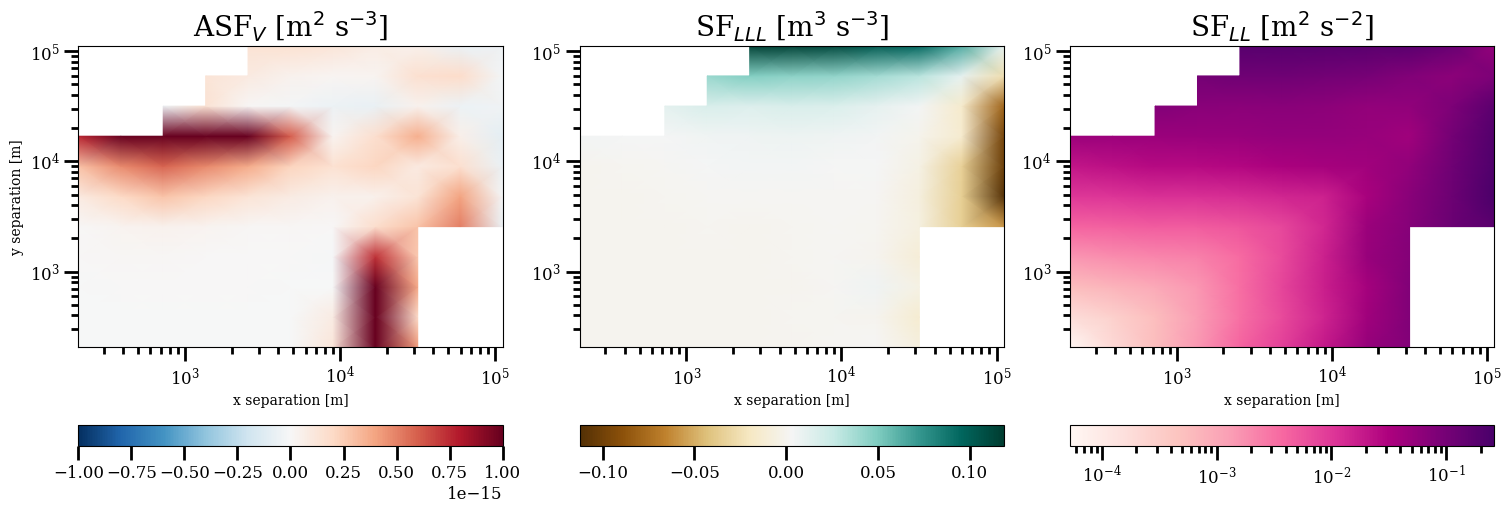

In [30]:
from matplotlib.colors import SymLogNorm

fig, axs = plt.subplots(1, 3, figsize=(15, 5), layout="constrained")

Advective = axs[0].pcolormesh(
    sf_adv.x,
    sf_adv.y,
    sf_adv.sf,
    vmin=-1.0e-15,
    vmax=1.0e-15,
    cmap=plt.cm.RdBu_r,
    shading='gouraud'
)
axs[0].set_xscale('log')
axs[0].set_yscale('log')
axs[0].set_xlabel("x separation [m]")
axs[0].set_ylabel("y separation [m]")
axs[0].set_title("ASF$_{V}$ [m$^2$ s$^{-3}$]", fontsize=20)

cbar = fig.colorbar(Advective, ax=axs[0], location="bottom")

LLL = axs[1].pcolormesh(
    sf_lll.x,
    sf_lll.y,
    sf_lll.sf,
    cmap=plt.cm.BrBG,
    shading='gouraud'

)
axs[1].set_xscale('log')
axs[1].set_yscale('log')

axs[1].set_xlabel("x separation [m]")
axs[1].set_title("SF$_{LLL}$ [m$^3$ s$^{-3}$]", fontsize=20)

cbar = fig.colorbar(LLL, ax=axs[1], location="bottom")
# cbar.set_ticks([-0.05, 0, 0.05])

LL = axs[2].pcolormesh(
    sf_ll.x,
    sf_ll.y,
    sf_ll.sf,
    norm=LogNorm(),
    cmap=plt.cm.RdPu,

    shading='gouraud'

)
axs[2].set_xscale('log')
axs[2].set_yscale('log')

axs[2].set_xlabel("x separation [m]")
axs[2].set_title("SF$_{LL}$ [m$^2$ s$^{-2}$]", fontsize=20)

cbar = fig.colorbar(LL, ax=axs[2], location="bottom")
# cbar.set_ticks([0, 1, 2])
axs[2].axhline(0, color="black", lw=0.5)
axs[2].axvline(0, color="black", lw=0.5)

plt.savefig('../figs/fig3.png',dpi=300,bbox_inches='tight')



In [26]:
sf_ll

<xarray.Dataset> Size: 5kB
Dimensions:       (y: 11, x: 11, edge: 2)
Coordinates:
  * x             (x) float64 88B 205.6 386.0 724.9 ... 5.969e+04 1.121e+05
  * y             (y) float64 88B 205.6 386.0 724.9 ... 5.969e+04 1.121e+05
Dimensions without coordinates: edge
Data variables:
    sf            (y, x) float64 968B 8.42e-05 0.0003115 ... 0.1304 0.05394
    sf_std        (y, x) float64 968B 4.338e-05 0.0001764 ... 0.02539 0.01722
    nbootstraps   (y, x) int64 968B 60 60 60 60 60 60 60 ... 60 60 60 60 60 60
    density       (y, x) float32 484B 1.0 0.3328 0.319 ... 0.0003663 0.0003657
    point_counts  (y, x) int64 968B 96 60 108 216 449 ... 1740 2784 5568 10440
    converged     (y, x) bool 121B True True True True ... True True True True
    x_bins        (x, edge) float64 176B 150.0 281.7 ... 8.18e+04 1.536e+05
    y_bins        (y, edge) float64 176B 150.0 281.7 ... 8.18e+04 1.536e+05
Attributes: (12/14)
    bin_type_x:                 logarithmic
    bin_type_y:                 logarithmic
    convergence_eps:            0.05
    max_nbootstrap:             420
    initial_nbootstrap:         60
    order:                      2
    ...                         ...
    variables:                  u,v
    bootstrappable_dimensions:  y,x
    time_dimensions:            
    backend:                    loky
    weighting:                  volume_element
    bootstrap_se_method:        unweighted_std